In [111]:
%load_ext autoreload
%autoreload 2
import main
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Parameters

In [120]:
rho = 1
d_list = [100, 200, 400, 800, 1600]
num_runs = 10
num_epochs = 50
sigma2 = 0.01

In [121]:
# Different covariance structures
cov_structures = {
    "identity": lambda d: np.eye(d),
    "diag_decreasing": lambda d: np.diag(np.linspace(1, 0.1, d)),
    "diag_increasing": lambda d: np.diag(np.linspace(0.1, 2, d)),
    "toeplitz": lambda d: np.array([[0.9**abs(i-j) for j in range(d)] for i in range(d)]),
    "low_rank": lambda d: (np.random.randn(d, 5) @ np.random.randn(5, d)),
    "max_neq_avg" : lambda d: main.diagonal_spike_cov(d)
}

## Figuring order of quantities empirically

We must find the size of some terms in order to determine $\gamma(d)$

In [122]:
for d in d_list:
    print(main.compute_first_term(d, d, 1/d * np.eye(d), sigma2, 1) * d)
    

3.4385588681408383
4.4244671317960425
3.3469104262314904
3.8491594538185945
4.4872267909227395


This suggests that $|| \nabla \hat{R}(\theta) ||^2$ grows in $O(1/d)$

In [123]:
for d in d_list:
    print(main.compute_second_term(d, d, 1/d * np.eye(d), sigma2, 1) * d**2)

6.075227881333972
7.223489174137772
13.279933674400372
9.279379567125112
8.61051434171417


This suggests that $ \nabla \hat{R} (\theta_{t-1})^T H \nabla \hat{R} (\theta_{t-1}) $ grows in $O(1/d^2)$

In [124]:
for d in d_list:
    print(main.compute_third_term_sgd(d, d, 1/d * np.eye(d), sigma2, 1) * d)

5.10352644054387
3.3538841319790618
3.8087838230399753
3.831753844445396
3.982117715347501


## Experiment 1 : Figuring out scaling on $\gamma$ in small batch SGD

### Effect of $\sigma^2$

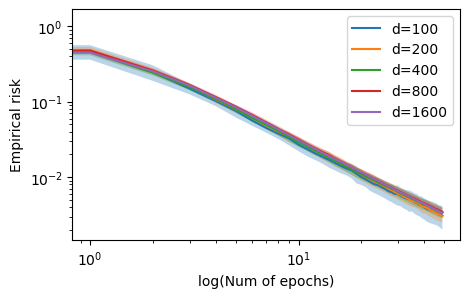

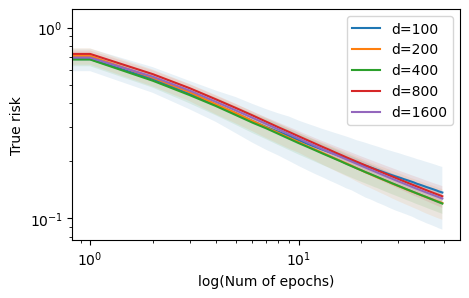

In [125]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:1, sigma_hat=cov_structures["identity"], step_type="max")

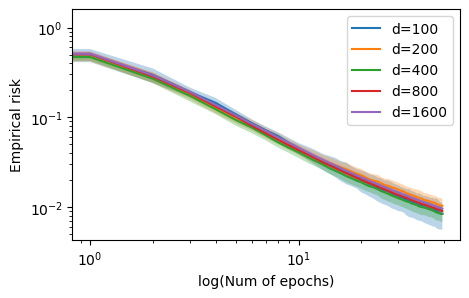

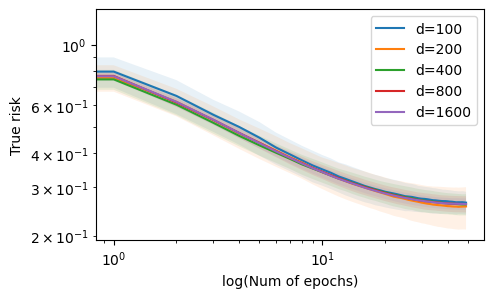

In [126]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2*10, main.run_sgd, gamma=lambda d:1, sigma_hat=cov_structures["identity"], step_type="max") 

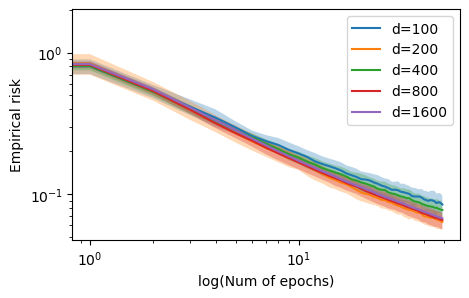

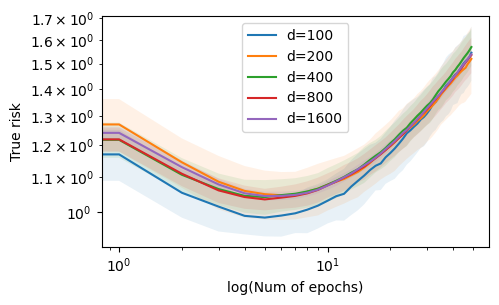

In [127]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2*100, main.run_sgd, gamma=lambda d:1, sigma_hat=cov_structures["identity"], step_type="max") 

### Without optimizing for the absolute cst

In [ ]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:1, sigma_hat=cov_structures["identity"]) 

### Setting the absolute constant to $ \frac{1}{\lambda_{max} (A^T A)} $

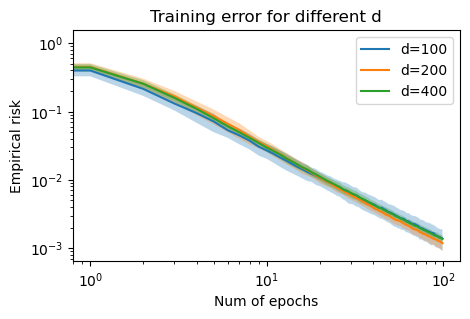

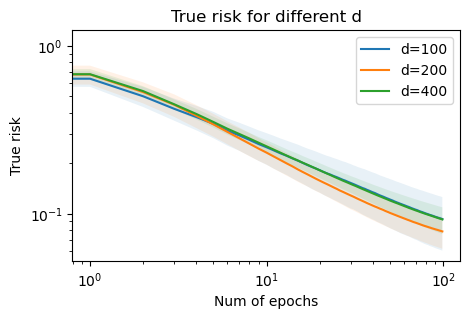

In [ ]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:1, sigma_hat=lambda d:cov_structures["identity"], step_type="max") 

### Setting the absolute constant to $ \frac{1}{\lambda_{avg} (A^T A)} $

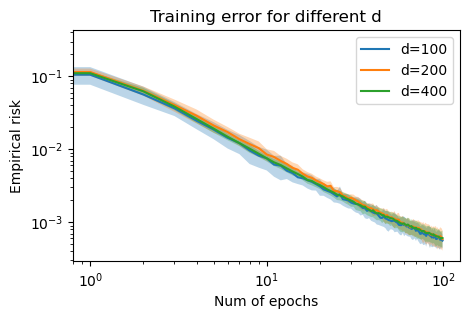

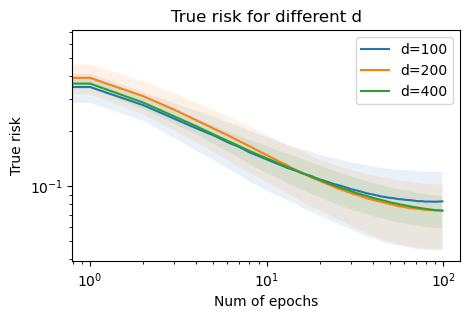

In [ ]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:1, sigma_hat=cov_structures["identity"], step_type="avg")

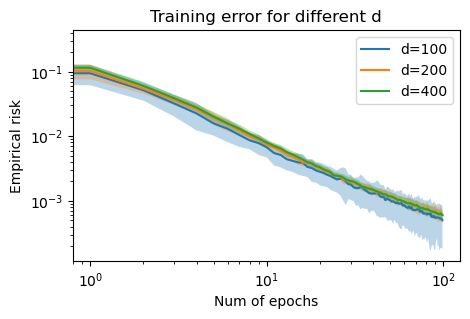

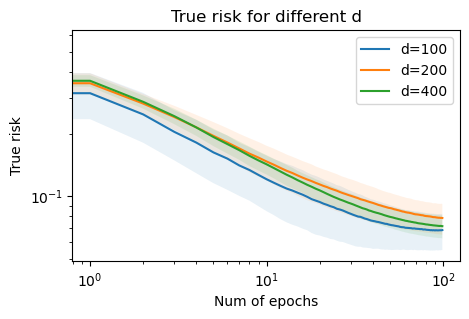

In [ ]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:1, sigma_hat=cov_structures["identity"], step_type="avg") 

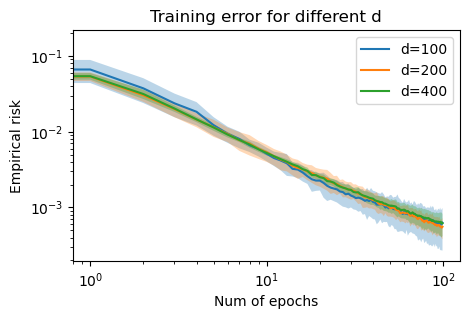

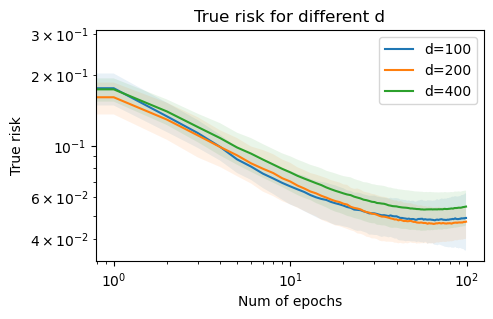

In [ ]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:1, sigma_hat=cov_structures["diag_decreasing"], step_type="avg") 

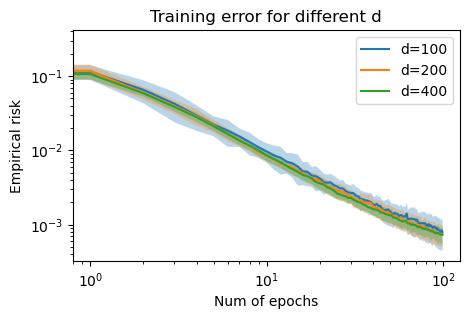

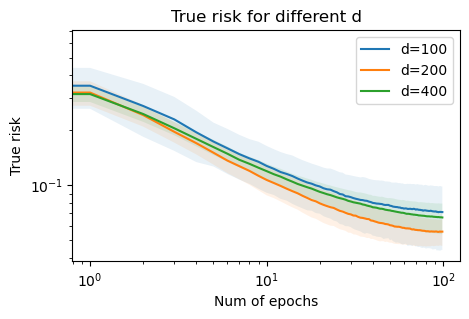

In [ ]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:1, sigma_hat=cov_structures["diag_increasing"], step_type="avg") 

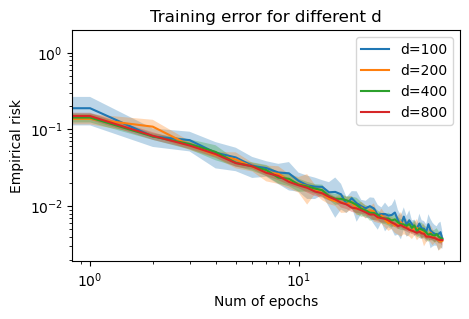

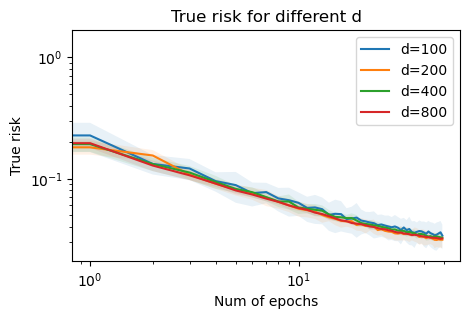

In [ ]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:1, sigma_hat=cov_structures["toeplitz"], step_type="avg") 

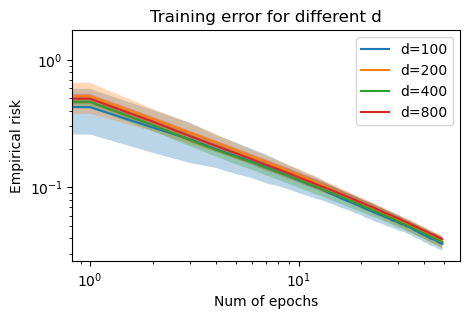

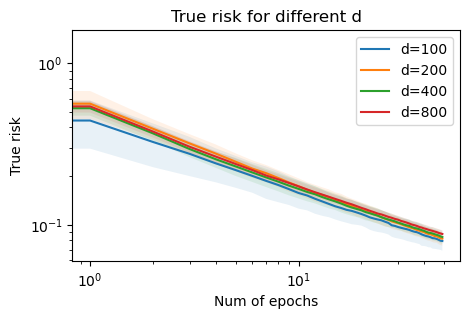

In [ ]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:1, sigma_hat=cov_structures["toeplitz"], step_type="max") 

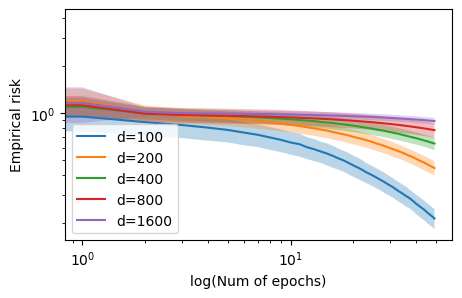

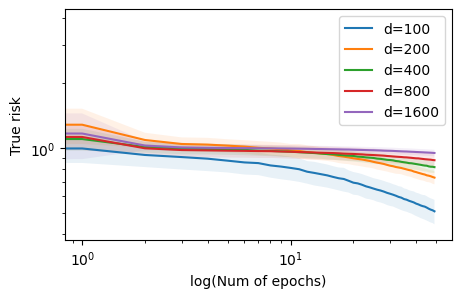

<Figure size 640x480 with 0 Axes>

In [ ]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:1, sigma_hat=cov_structures["max_neq_avg"], step_type="max") 

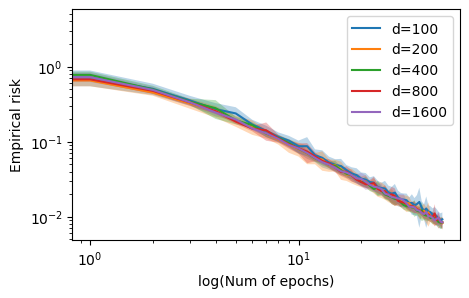

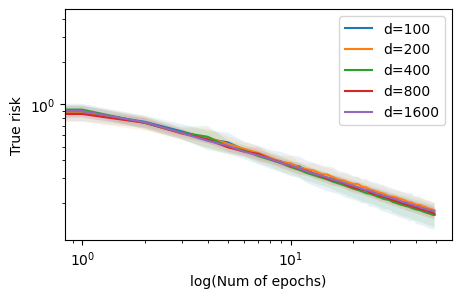

<Figure size 640x480 with 0 Axes>

In [ ]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:1/4, sigma_hat=cov_structures["max_neq_avg"], step_type="avg") 

## Experiment 2 : Effect of randomness in SGD

### Single shuffle sgd

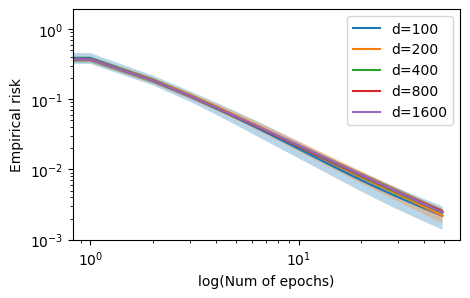

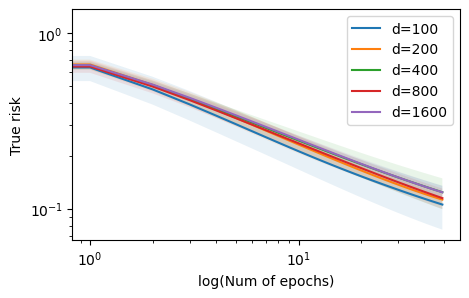

<Figure size 640x480 with 0 Axes>

In [ ]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.single_suffle_sgd, gamma=lambda d:1, sigma_hat=cov_structures["identity"], step_type="max") 

### Multiple shuffle sgd

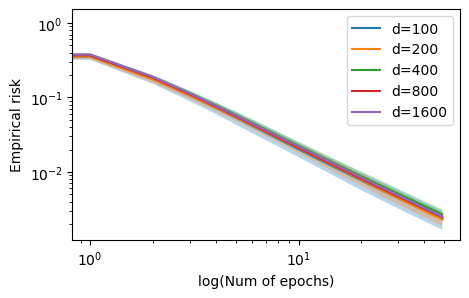

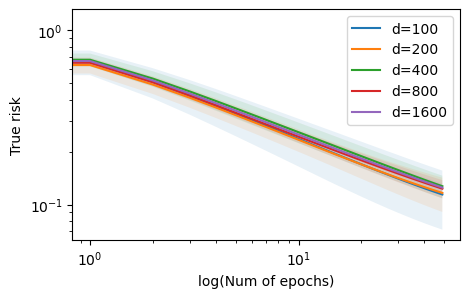

In [ ]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.multiple_shuffle_sgd, gamma=lambda d:1, sigma_hat=cov_structures["identity"], step_type="max") 

## Experiment 3 : SGD with momentum

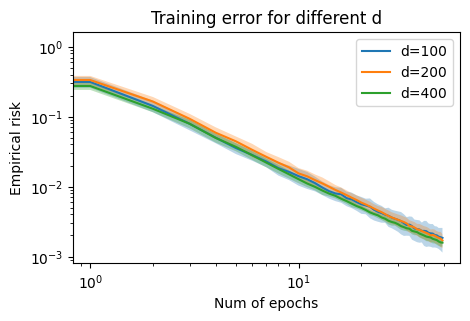

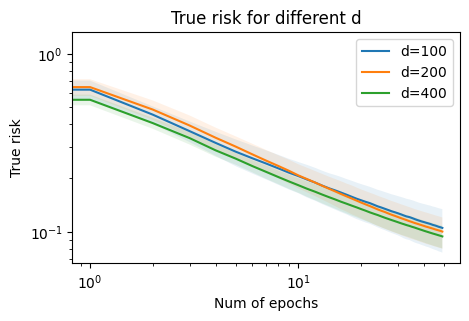

In [ ]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_momentum_fixed_delta, gamma=lambda d:1, sigma_hat=cov_structures["identity"], step_type="max")

## Experiment 4 : Small vs large batch sizes

### Full batch $ ( \left |B| = n^1 \right )$ 

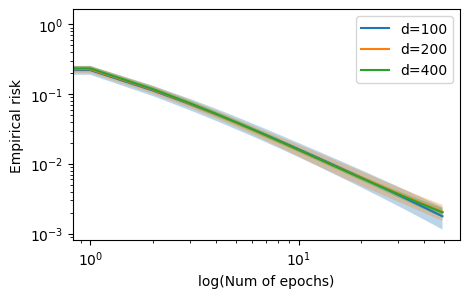

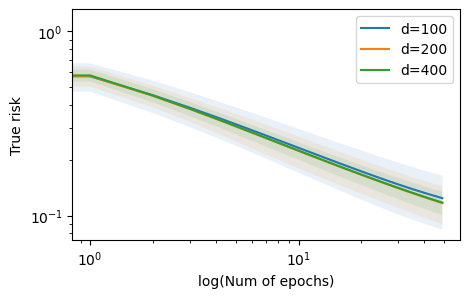

In [55]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_batch, gamma=lambda d:1/3 * d, sigma_hat=cov_structures["identity"], batch_size=lambda n:n, step_type= None)

### $\eta=0.8$ regime $ ( \left |B| = n^{0.8} \right )$ 

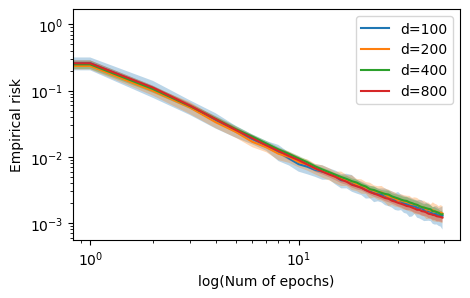

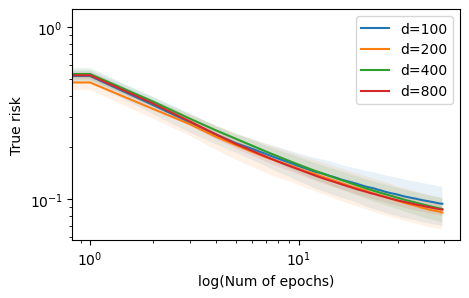

In [ ]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_batch, gamma=lambda d: d**0.8, sigma_hat=cov_structures["identity"], batch_size=lambda n:int(n**0.8), step_type= "avg")

### $\eta=0.6$ regime $ ( \left |B| = n^{0.6} \right )$ 

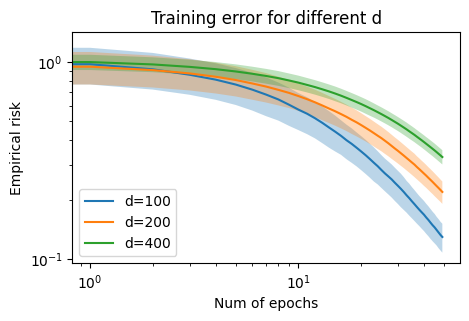

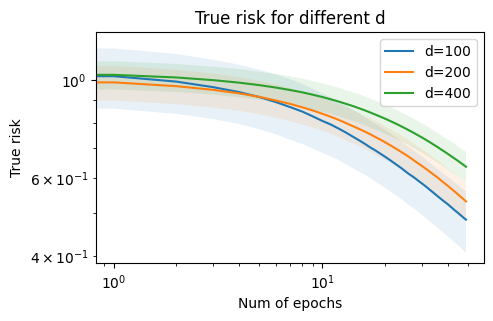

In [ ]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_batch, gamma=lambda d:d**0.6, sigma_hat=cov_structures["identity"], batch_size=lambda n:int(n**0.6), step_type= "max")

### $\eta=0.4$ regime $ ( \left |B| = n^{0.4} \right )$ 

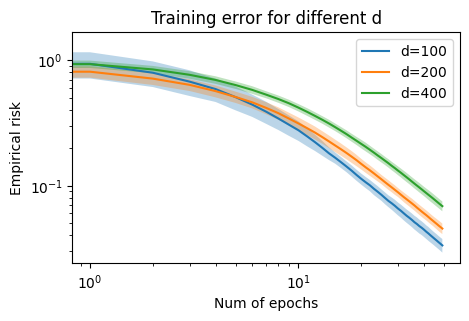

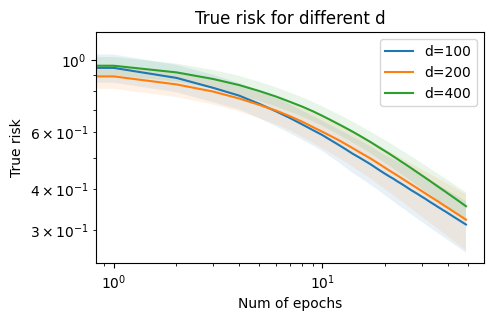

In [ ]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_batch, gamma=lambda d:d**0.4, sigma_hat=cov_structures["identity"], batch_size=lambda n:int(n**0.4), step_type= "max")

### $\eta=0.2$ regime $ ( \left |B| = n^{0.2} \right )$ 

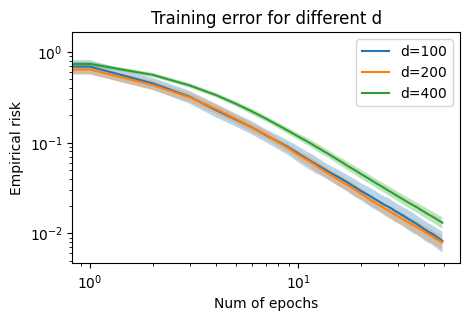

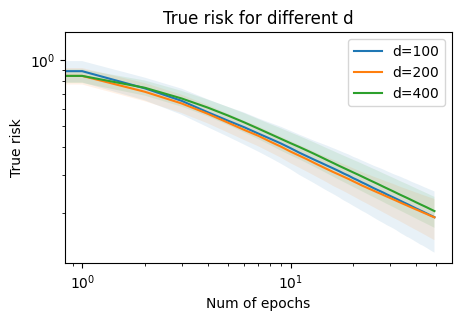

In [ ]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_batch, gamma=lambda d:d**0.2, sigma_hat=cov_structures["identity"], batch_size=lambda n:int(n**0.2), step_type= "max")

## Experiment 4 Optional Experiment: Small vs large batch sizes with momentum

### $\xi=0.2$ regime $ ( \left |B| = 0.2n \right )$ 

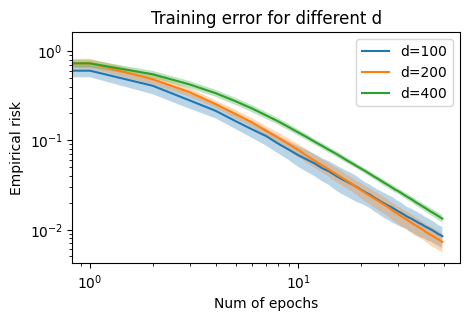

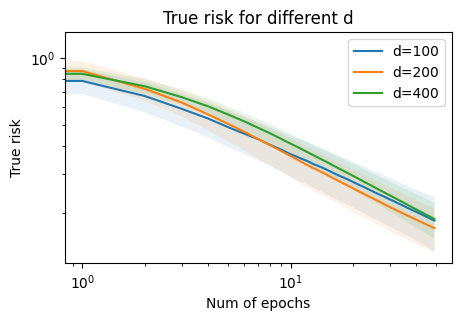

In [87]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_batch, gamma=lambda d:d**1, sigma_hat=cov_structures["identity"], batch_size=lambda n:int(n**0.2), step_type= "max")

### $\xi=0.4$ regime $ ( \left |B| = 0.4n \right )$ 

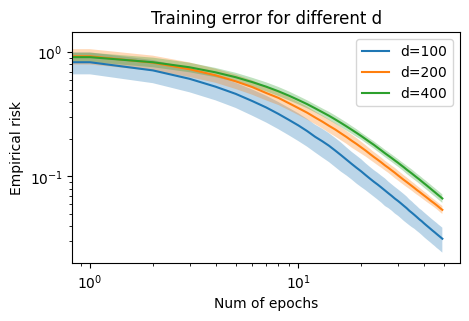

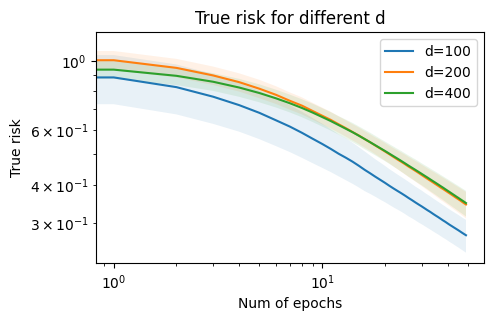

In [88]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_batch, gamma=lambda d:d**1, sigma_hat=cov_structures["identity"], batch_size=lambda n:int(n**0.4), step_type= "max")

### $\xi=0.5$ regime $ ( \left |B| = 0.5n \right )$ 

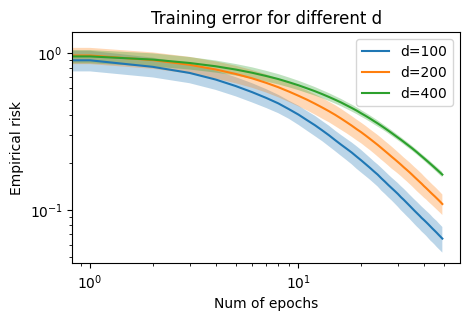

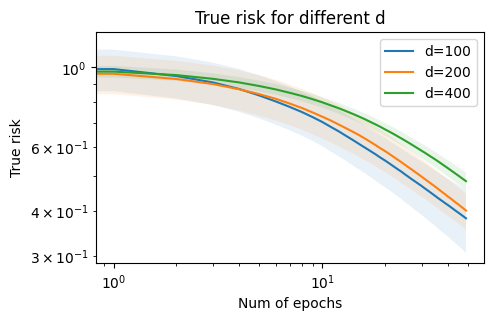

In [91]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_batch, gamma=lambda d:d**1, sigma_hat=cov_structures["identity"], batch_size=lambda n:int(n**0.5), step_type= "max")

### $\xi=0.6$ regime $ ( \left |B| = 0.6n \right )$ 

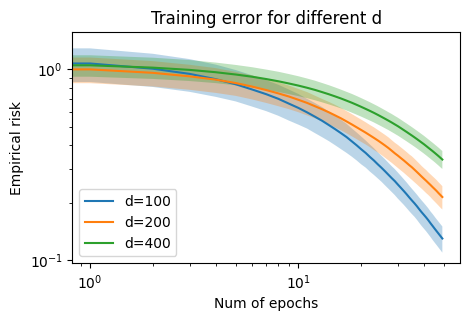

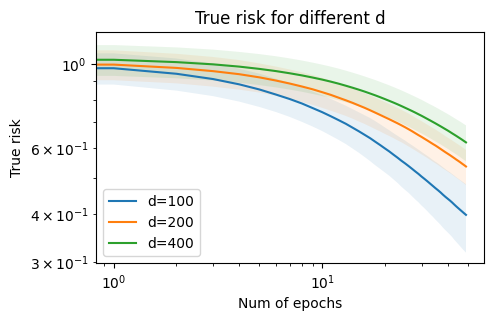

In [89]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_batch, gamma=lambda d:d**1, sigma_hat=cov_structures["identity"], batch_size=lambda n:int(n**0.6), step_type= "max")

### $\xi=0.8$ regime $ ( \left |B| = 0.8n \right )$ 

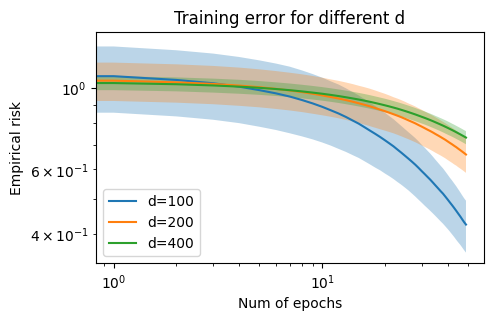

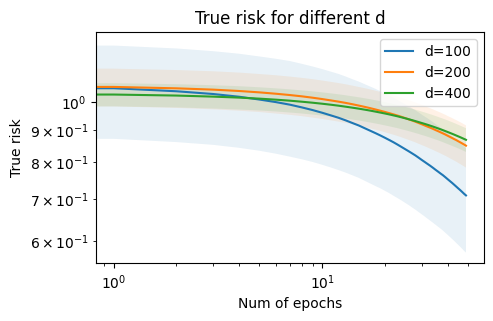

In [90]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_batch, gamma=lambda d:d**1, sigma_hat=cov_structures["identity"], batch_size=lambda n:int(n**0.8), step_type= "max")